<a href="https://colab.research.google.com/github/F-Abir/GEE-Python-API/blob/main/Precipitation_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import ee
import geemap as gee
import xarray as xr

In [ ]:
!pip install xee
import xee

In [3]:
ee.Authenticate()
ee.Initialize(project = 'ee-abirnahraf', opt_url = 'https://earthengine-highvolume.googleapis.com')


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_7TDKVSyKvBdmMqW?ref=4i2o6


In [ ]:
# Load the FAO GAUL Administrative Unit Level 0 dataset.
admin0 = ee.FeatureCollection("FAO/GAUL_SIMPLIFIED_500m/2015/level2")

# Filter the collection to get the boundaries for Bangladesh.
bangladesh_boundary = admin0.filter(ee.Filter.eq('ADM0_NAME', 'Bangladesh'))

# Print the boundary information (optional)
display(bangladesh_boundary.first())

In [ ]:
map.addLayer(bangladesh_boundary, {}, 'Bangladesh Boundary')
map.centerObject(bangladesh_boundary, 8)

In [ ]:
map = gee.Map(basemap = 'ROADMAP')
map

In [ ]:
# Merge the polygons in the bangladesh_boundary FeatureCollection.
AOI = bangladesh_boundary.union()

# Print the merged boundary information (optional)
display(AOI.first())

In [11]:
map.addLayer(AOI, {}, 'AOI')
map.centerObject(AOI, 8)

In [16]:
# Load the CHIRPS daily precipitation dataset.
chirps = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')

# Filter the dataset by date.
chirps_filtered = chirps.filterDate('2001-01-01', '2025-01-01')

# Print information about the filtered dataset (optional)
display(chirps_filtered.first())

In [17]:
# Get the number of images in the filtered collection.
number_of_images = chirps_filtered.size().getInfo()

# Print the number of images.
print(f"Number of images in chirps_filtered: {number_of_images}")

Number of images in chirps_filtered: 8766


In [ ]:
ds = xr.open_dataset(chirps_filtered, engine = 'ee', crs = 'EPSG:4326', geometry = AOI.geometry(), scale = 0.27)
ds

In [ ]:
ds_mean = ds.mean('time')

ds_mean

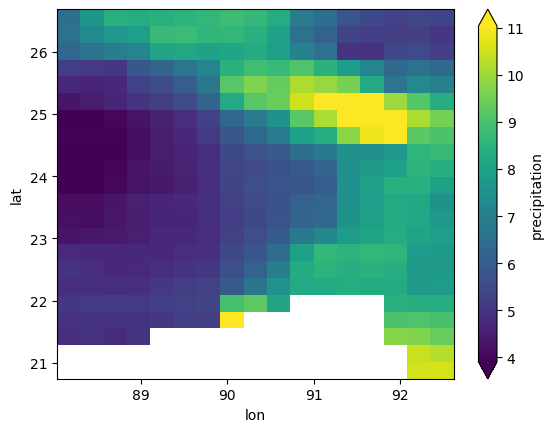

In [23]:
ds_mean.precipitation.plot(x = 'lon', y = 'lat', robust = True)

In [ ]:
ds_var = ds.var('time')

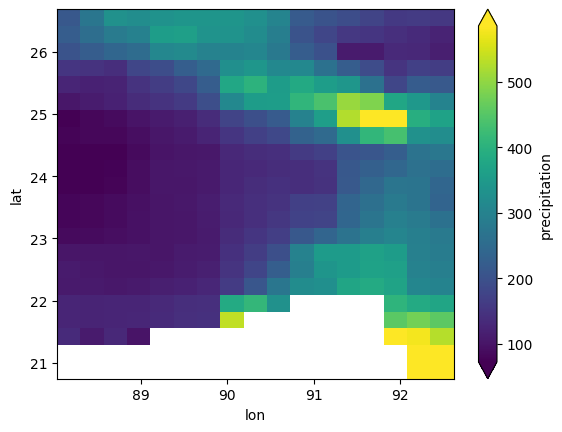

In [25]:
ds_var.precipitation.plot(x = 'lon', y = 'lat', robust = True)


In [ ]:
monthly = ds.resample(time = 'M').sum()

monthly

In [ ]:
point = monthly.sel(lon = 48.73310048088049, lat = 31.808809525085334, method ='nearest')

point

In [ ]:
df = point.to_dataframe()['precipitation']

df

<Axes: xlabel='time'>

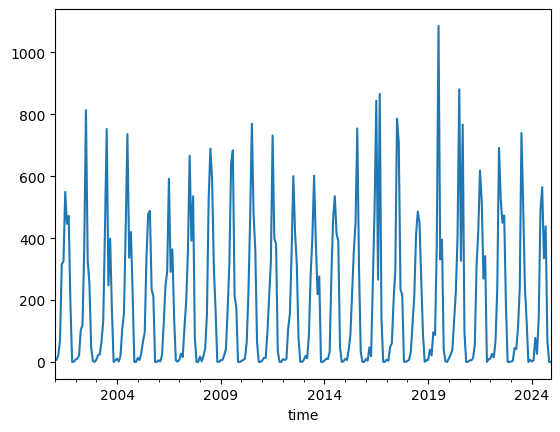

In [29]:
df.plot()


In [30]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [31]:
model = SARIMAX(df, order = (1,1,1), seasonal_order = (1,1,0,48)) # this gives a better result
result = model.fit()

In [32]:
result

In [33]:
forecast = result.get_forecast(steps = 10 * 12)

<Axes: xlabel='time'>

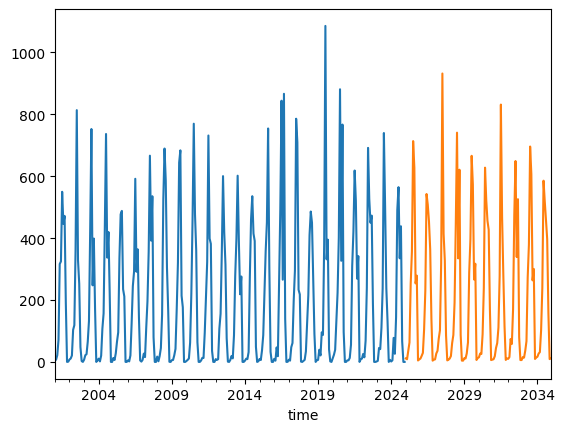

In [34]:
df.plot()
forecast.predicted_mean.plot()

In [35]:
forecast.predicted_mean.to_csv('pr_forecasted.csv')

In [36]:
from google.colab import files

files.download('pr_forecasted.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>